In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Load dataset (make sure the file is uploaded in Colab)
df = pd.read_csv("CO2 Emissions_Canada (1).csv")

# Display first few rows
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
# Selecting feature and target
X = df[["Engine Size(L)"]]   # Feature (must be 2D)
y = df["CO2 Emissions(g/km)"]  # Target

# Check shape
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7385, 1)
Target shape: (7385,)


In [4]:
# Create model
model = LinearRegression()

# Fit model
model.fit(X, y)

# Extract coefficient β1
beta_1 = model.coef_[0]

print("Estimated β1 (Slope):", beta_1)

Estimated β1 (Slope): 36.77731518641943


In [5]:
# Bootstrap parameters
B = 2000
n = len(df)

bootstrap_betas = []

for i in range(B):
    # Resample indices with replacement
    sample_indices = np.random.choice(n, n, replace=True)

    X_sample = X.iloc[sample_indices]
    y_sample = y.iloc[sample_indices]

    # Fit model on bootstrap sample
    model_sample = LinearRegression()
    model_sample.fit(X_sample, y_sample)

    # Store beta
    bootstrap_betas.append(model_sample.coef_[0])

bootstrap_betas = np.array(bootstrap_betas)

In [6]:
ci_90 = np.percentile(bootstrap_betas, [5, 95])
print("90% Confidence Interval for β1:", ci_90)

90% Confidence Interval for β1: [36.2686914  37.28926912]


In [7]:
ci_95 = np.percentile(bootstrap_betas, [2.5, 97.5])
print("95% Confidence Interval for β1:", ci_95)

95% Confidence Interval for β1: [36.19060876 37.38931397]


In [8]:
print("Width of 90% CI:", ci_90[1] - ci_90[0])
print("Width of 95% CI:", ci_95[1] - ci_95[0])

Width of 90% CI: 1.0205777185341915
Width of 95% CI: 1.1987052104310862


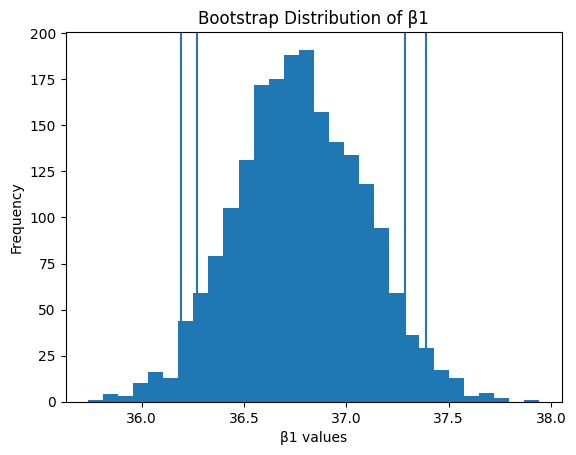

In [9]:
plt.hist(bootstrap_betas, bins=30)
plt.axvline(ci_90[0])
plt.axvline(ci_90[1])
plt.axvline(ci_95[0])
plt.axvline(ci_95[1])
plt.title("Bootstrap Distribution of β1")
plt.xlabel("β1 values")
plt.ylabel("Frequency")
plt.show()

Conclusion:
Engine Size has a significant positive effect on CO₂ emissions.
Larger engine size → higher CO₂ emissions.
